In [1]:
#1. Load --> Data, Model
#2. Preprocess
#3. Split ( Train, Test)
#4. Design and Implement out model. 
#5. Train
#6. Evaluate
#7. Predict

# Import Libraries

In [2]:
import os
import time
import json

import keras
import cv2

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from keras.datasets import mnist
from keras.models import Sequential
from keras import layers
from keras.layers import Dense


from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix
)

I0000 00:00:1788814271.688825   22425 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1788814271.689424   22425 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1788814271.771416   22425 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1788814273.489912   22425 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.

# Load MNIST Dataset

In [3]:
(train_images, train_labels), (test_images, test_labels) = mnist.load_data()

print(f"Training images: {train_images.shape}")
print(f"Training labels: {train_labels.shape}")
print(f"Test images: {test_images.shape}")
print(f"Test labels: {test_labels.shape}")

Training images: (60000, 28, 28)
Training labels: (60000,)
Test images: (10000, 28, 28)
Test labels: (10000,)


## Visualize Sample Images

Before preprocessing, we visualize some examples from the MNIST dataset.

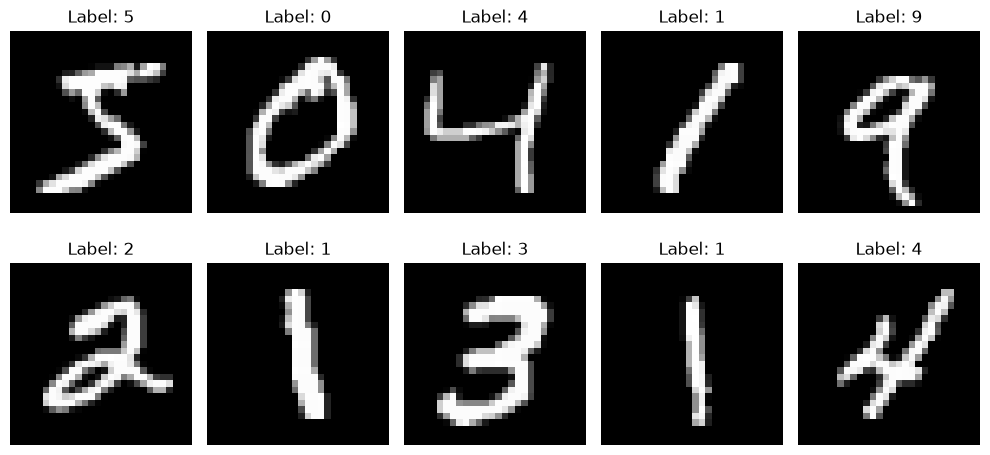

In [4]:
plt.figure(figsize=(10, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(train_images[i], cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

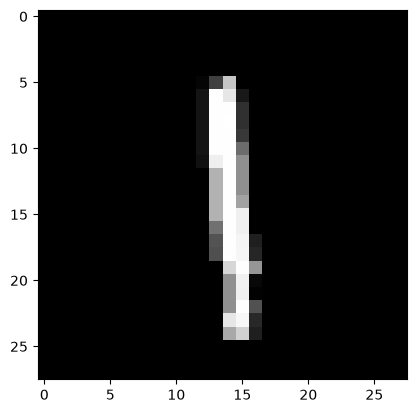

In [5]:
plt.imshow(train_images[8], cmap='gray')

In [6]:
train_labels[8]

np.uint8(1)

## One-Hot Encode Labels

The digit labels are converted into one-hot encoded vectors.

For example:

7 → [0, 0, 0, 0, 0, 0, 0, 1, 0, 0]

In [7]:
train_labels = keras.utils.to_categorical(train_labels)
test_labels = keras.utils.to_categorical(test_labels)

In [8]:
train_labels[8]

array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0.])

# Normalize Images

Pixel values in MNIST range from 0 to 255.

We normalize them to the range [0, 1] to make the training process
more stable and efficient.

In [9]:
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

In [10]:
train_images[5]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

# Prepare Data for Dense FFNN

## Flatten Images for Dense FFNN

A Dense Neural Network expects a one-dimensional input vector.

Each MNIST image has a shape of:

28 × 28 = 784

Therefore, each image is flattened into a vector of 784 values.

In [11]:
train_images_ffnn = train_images.reshape(60000, 784)
test_images_ffnn = test_images.reshape(10000, 784)

In [12]:
print("FFNN training shape:", train_images_ffnn.shape)
print("FFNN test shape:", test_images_ffnn.shape)

FFNN training shape: (60000, 784)
FFNN test shape: (10000, 784)


In [13]:
train_images_ffnn[5].shape

(784,)

## Data for CNN

# Prepare Images for CNN

CNN models expect image data in the following format:

(height, width, channels)

MNIST images are grayscale, so they have one channel.

Therefore, the input shape becomes:

28 × 28 × 1

In [14]:
train_images_cnn = np.expand_dims(train_images, axis=-1)
test_images_cnn = np.expand_dims(test_images, axis=-1)

In [15]:
train_images_cnn = np.expand_dims(train_images, axis=-1)
test_images_cnn = np.expand_dims(test_images, axis=-1)

In [16]:
print("CNN training shape:", train_images_cnn.shape)
print("CNN test shape:", test_images_cnn.shape)

CNN training shape: (60000, 28, 28, 1)
CNN test shape: (10000, 28, 28, 1)


In [17]:
train_images_ffnn[5]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

# Build Dense FFNN

## Dense Feedforward Neural Network

The Dense FFNN receives the flattened 784-dimensional image.

Architecture:

Input: 784

↓

Dense: 128 neurons + ReLU

↓

Dense: 64 neurons + ReLU

↓

Output: 10 neurons + Softmax

In [18]:
## Design the model ffnn

model_ffnn = Sequential()
model_ffnn.add(Dense(128, activation="relu", input_shape=(784,))) #Dense, 128, Relu
model_ffnn.add(Dense(64, activation='relu'))#Dense, 64, Relu
model_ffnn.add(Dense(10, activation='softmax'))#Dense, 10, Softmax

/workspaces/mini-deep-learning-experiment/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
E0000 00:00:1788814277.638094   22425 cuda_platform.cc:52] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


## Compile FFNN

In [19]:
model_ffnn.compile(optimizer='adam',loss='categorical_crossentropy', metrics=['accuracy'])

# FFNN Summary

In [20]:
model_ffnn.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

# Build CNN



## Convolutional Neural Network

# The CNN processes the original spatial

# structure of the image.


Architecture:

Input: 28 × 28 × 1

↓

Conv2D: 32 filters

↓

MaxPooling

↓

Conv2D: 64 filters

↓

MaxPooling

↓

Conv2D: 128 filters

↓

MaxPooling

↓

Flatten

↓

Dense: 10 neurons

↓

Output: 10 classes

In [21]:
#Design
model_cnn = Sequential()

#Feature Extraction part
model_cnn.add(layers.Conv2D(
     32,
     kernel_size=(3, 3),
     padding='same',
     activation ='relu', 
     strides=(1, 1), 
     input_shape=(28, 28, 1)))

model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

model_cnn.add(layers.Conv2D(
    64, 
    kernel_size=(3, 3), 
    padding='same', 
    activation = 'relu', 
    strides=(1, 1)))

model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

model_cnn.add(layers.Conv2D(
    128, 
    kernel_size=(3, 3), 
    padding='same', 
    activation='relu', 
    strides=(1, 1)))
model_cnn.add(layers.MaxPool2D(pool_size=(2, 2)))

#Classification
model_cnn.add(layers.Flatten())
model_cnn.add(layers.Dense(10, activation='softmax'))

/workspaces/mini-deep-learning-experiment/.venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Compile CNN

In [22]:
model_cnn.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
     metrics=['accuracy'])

# CNN Summary

In [23]:
model_cnn.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 104,202 (407.04 KB)

 Trainable params: 104,202 (407.04 KB)

 Non-trainable params: 0 (0.00 B)

# Compare Number of Parameters
## Model Complexity

We compare the number of trainable parameters in both models.

In [24]:
ffnn_params = model_ffnn.count_params()
cnn_params = model_cnn.count_params()

print(f"Dense FFNN Parameters: {ffnn_params:,}")
print(f"CNN Parameters: {cnn_params:,}")

Dense FFNN Parameters: 109,386
CNN Parameters: 104,202


## Train Dense FFNN

The Dense FFNN is trained for 10 epochs using a batch size of 128.

Training time is measured for comparison with the CNN.

In [25]:
start_time = time.time()

ffnn_history = model_ffnn.fit(
    train_images_ffnn,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

ffnn_training_time = time.time() - start_time

print(f"FFNN Training Time: {ffnn_training_time:.2f} seconds")

Epoch 1/5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9244 - loss: 0.2548 - val_accuracy: 0.9655 - val_loss: 0.1170
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9672 - loss: 0.1077 - val_accuracy: 0.9718 - val_loss: 0.0897
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9770 - loss: 0.0741 - val_accuracy: 0.9773 - val_loss: 0.0740
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9812 - loss: 0.0577 - val_accuracy: 0.9762 - val_loss: 0.0831
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9847 - loss: 0.0460 - val_accuracy: 0.9763 - val_loss: 0.0816
FFNN Training Time: 22.34 seconds


# Train CNN

In [26]:
start_time = time.time()

cnn_history = model_cnn.fit(
    train_images_cnn,
    train_labels,
    epochs=5,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

cnn_training_time = time.time() - start_time

print(f"CNN Training Time: {cnn_training_time:.2f} seconds")

Epoch 1/5


1688/1688 ━━━━━━━━━━━━━━━━━━━━ 29s 16ms/step - accuracy: 0.9569 - loss: 0.1394 - val_accuracy: 0.9857 - val_loss: 0.0464
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9876 - loss: 0.0401 - val_accuracy: 0.9887 - val_loss: 0.0410
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9911 - loss: 0.0273 - val_accuracy: 0.9892 - val_loss: 0.0356
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 27s 16ms/step - accuracy: 0.9929 - loss: 0.0212 - val_accuracy: 0.9918 - val_loss: 0.0283
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 28s 16ms/step - accuracy: 0.9945 - loss: 0.0169 - val_accuracy: 0.9928 - val_loss: 0.0274
CNN Training Time: 151.76 seconds


# Save Training Histories

In [27]:
os.makedirs("results", exist_ok=True)

with open("results/history_ffnn.json", "w") as file:
    json.dump(ffnn_history.history, file, indent=4)

with open("results/history_cnn.json", "w") as file:
    json.dump(cnn_history.history, file, indent=4)

print("Training histories saved successfully.")

Training histories saved successfully.


# Save Trained Models

In [28]:
os.makedirs("models", exist_ok=True)

model_ffnn.save("models/dense_ffnn.keras")
model_cnn.save("models/cnn.keras")

print("Models saved successfully.")

Models saved successfully.


# Make Predictions
The trained models are used to predict the classes of the MNIST test set.

In [29]:
ffnn_probabilities = model_ffnn.predict(
    test_images_ffnn,
    verbose=0
)

ffnn_predictions = np.argmax(
    ffnn_probabilities,
    axis=1
)

In [30]:
cnn_probabilities = model_cnn.predict(
    test_images_cnn,
    verbose=0
)

cnn_predictions = np.argmax(
    cnn_probabilities,
    axis=1
)

In [31]:
test_labels_original = np.argmax(test_labels, axis=1)

# Calculate Metrics
## Model Evaluation

We evaluate both models using:

- Accuracy
- Precision
- Recall
- F1-Score

In [32]:
ffnn_accuracy = accuracy_score(
    test_labels_original,
    ffnn_predictions
)

ffnn_precision = precision_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

ffnn_recall = recall_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

ffnn_f1 = f1_score(
    test_labels_original,
    ffnn_predictions,
    average="weighted",
    zero_division=0
)

In [33]:
cnn_accuracy = accuracy_score(
    test_labels_original,
    cnn_predictions
)

cnn_precision = precision_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_recall = recall_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

cnn_f1 = f1_score(
    test_labels_original,
    cnn_predictions,
    average="weighted",
    zero_division=0
)

In [34]:
# Print Results
print("Dense FFNN")
print(f"Accuracy : {ffnn_accuracy:.4f}")
print(f"Precision: {ffnn_precision:.4f}")
print(f"Recall   : {ffnn_recall:.4f}")
print(f"F1-Score : {ffnn_f1:.4f}")

print("\nCNN")
print(f"Accuracy : {cnn_accuracy:.4f}")
print(f"Precision: {cnn_precision:.4f}")
print(f"Recall   : {cnn_recall:.4f}")
print(f"F1-Score : {cnn_f1:.4f}")

Dense FFNN
Accuracy : 0.9719
Precision: 0.9721
Recall   : 0.9719
F1-Score : 0.9719

CNN
Accuracy : 0.9915
Precision: 0.9915
Recall   : 0.9915
F1-Score : 0.9915


# Confusion Matrix — FFNN

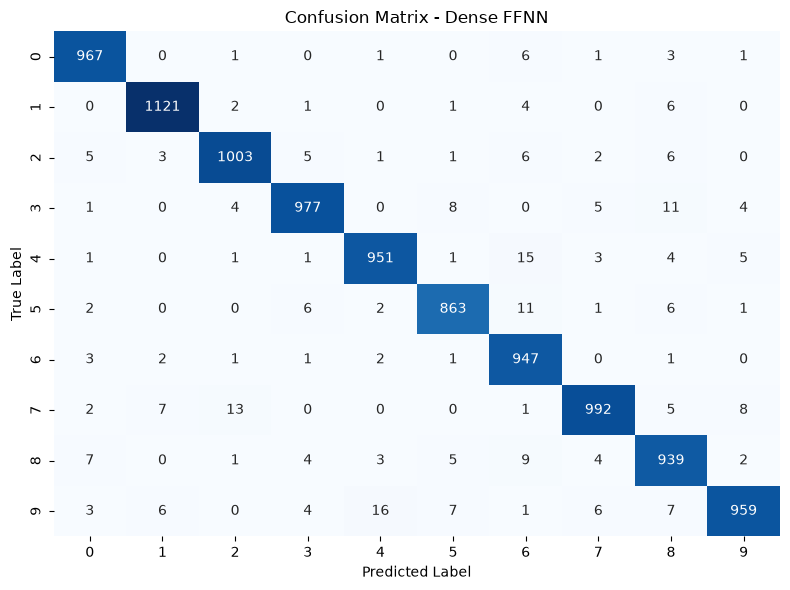

In [35]:
os.makedirs("plots", exist_ok=True)

ffnn_cm = confusion_matrix(
    test_labels_original,
    ffnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    ffnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - Dense FFNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_ffnn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Confusion Matrix — CNN

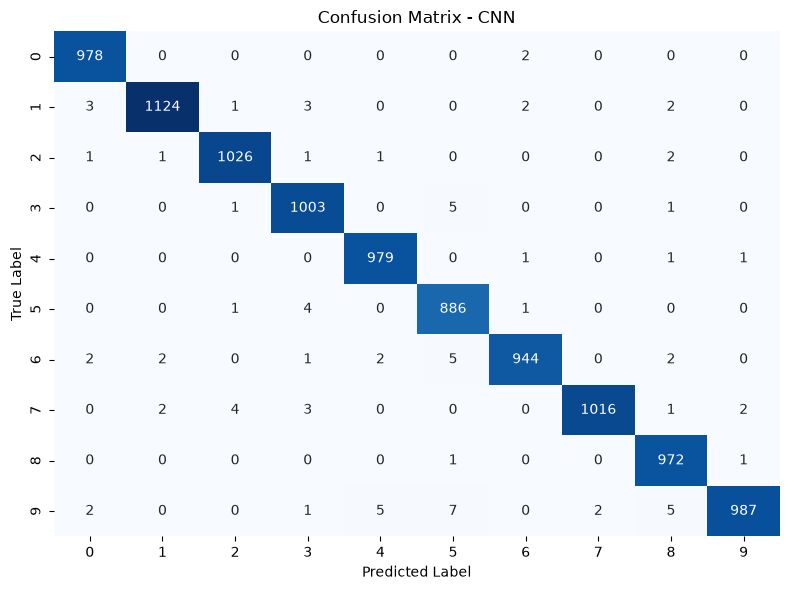

In [36]:
cnn_cm = confusion_matrix(
    test_labels_original,
    cnn_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cnn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix - CNN")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.tight_layout()

plt.savefig(
    "plots/confusion_matrix_cnn.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Accuracy Curves
This plot compares training and validation accuracy of the two models
during training.

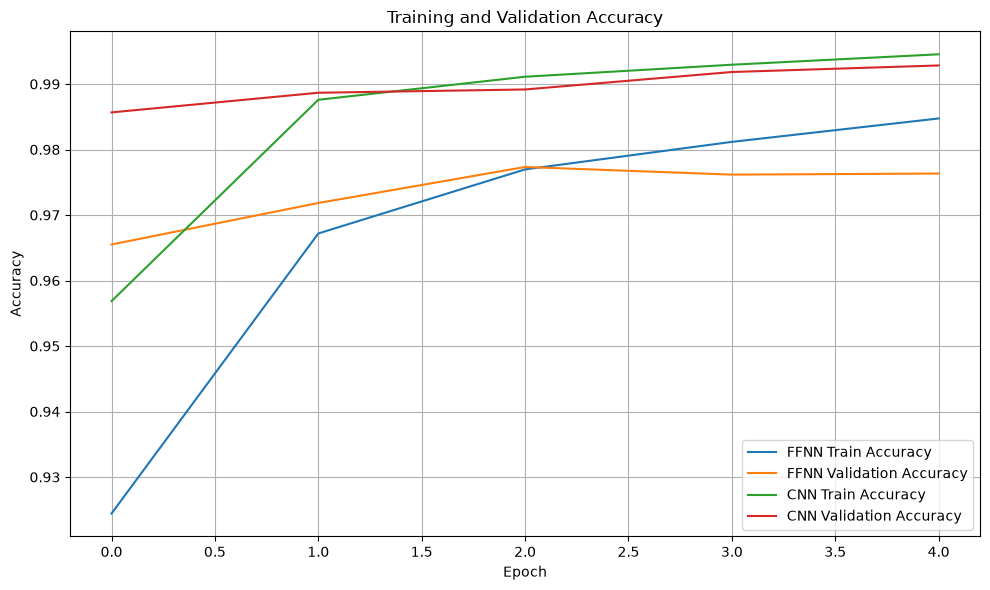

In [37]:
plt.figure(figsize=(10, 6))

plt.plot(
    ffnn_history.history["accuracy"],
    label="FFNN Train Accuracy"
)

plt.plot(
    ffnn_history.history["val_accuracy"],
    label="FFNN Validation Accuracy"
)

plt.plot(
    cnn_history.history["accuracy"],
    label="CNN Train Accuracy"
)

plt.plot(
    cnn_history.history["val_accuracy"],
    label="CNN Validation Accuracy"
)

plt.title("Training and Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "plots/accuracy_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Loss Curves

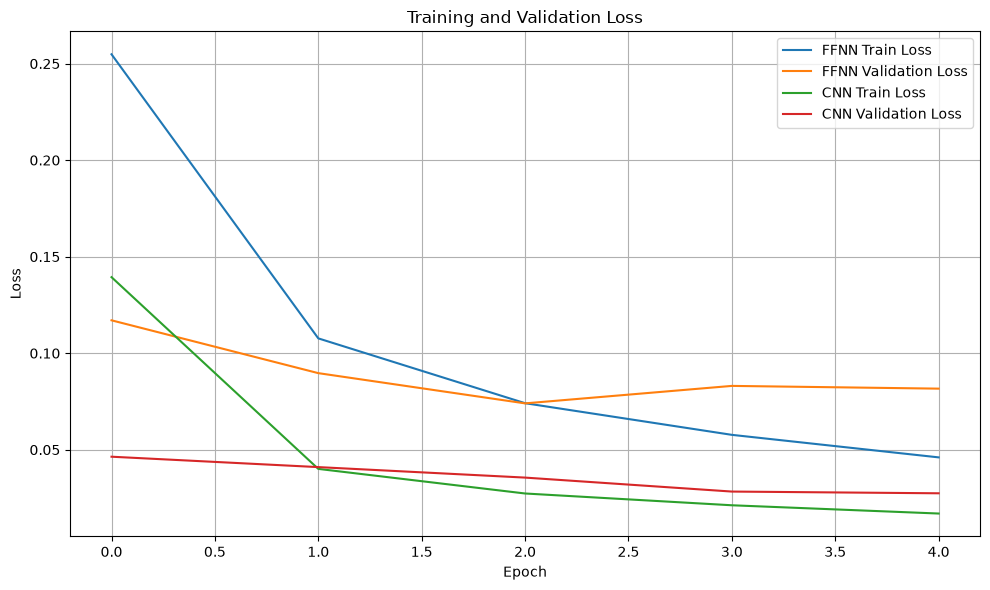

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    ffnn_history.history["loss"],
    label="FFNN Train Loss"
)

plt.plot(
    ffnn_history.history["val_loss"],
    label="FFNN Validation Loss"
)

plt.plot(
    cnn_history.history["loss"],
    label="CNN Train Loss"
)

plt.plot(
    cnn_history.history["val_loss"],
    label="CNN Validation Loss"
)

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()

plt.savefig(
    "plots/loss_curves.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Create Comparison DataFrame
## Model Comparison

The performance of both models is summarized in a single DataFrame.

In [39]:
results_df = pd.DataFrame({
    "Model": [
        "Dense FFNN",
        "CNN"
    ],

    "Test Accuracy": [
        ffnn_accuracy,
        cnn_accuracy
    ],

    "Precision": [
        ffnn_precision,
        cnn_precision
    ],

    "Recall": [
        ffnn_recall,
        cnn_recall
    ],

    "F1-Score": [
        ffnn_f1,
        cnn_f1
    ],

    "Training Time (sec)": [
        ffnn_training_time,
        cnn_training_time
    ],

    "Parameters": [
        ffnn_params,
        cnn_params
    ]
})

results_df

,Model,Test Accuracy,Precision,Recall,F1-Score,Training Time (sec),Parameters
0,Dense FFNN,0.9719,0.972066,0.9719,0.971901,22.335152,109386
1,CNN,0.9915,0.991541,0.9915,0.991498,151.761999,104202


In [40]:
results_df.to_csv(
    "results/comparison_results.csv",
    index=False
)

# Test Accuracy Comparison

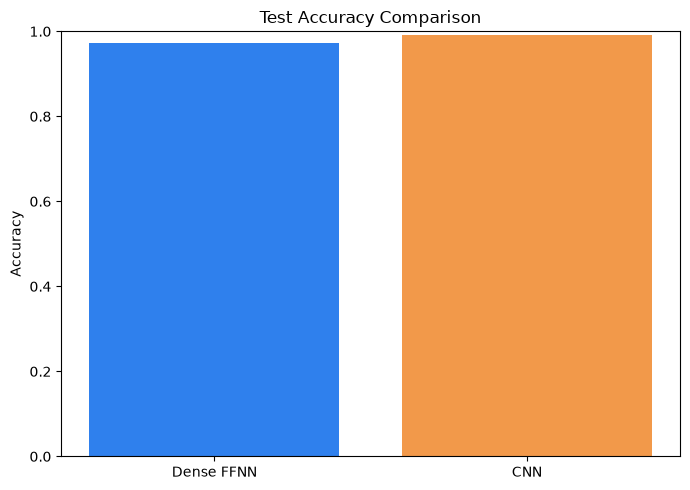

In [41]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["Test Accuracy"],
    color=["#2F80ED", "#F2994A"]
)

plt.title("Test Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0, 1)

plt.tight_layout()

plt.savefig(
    "plots/test_accuracy_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Precision / Recall / F1 Comparison

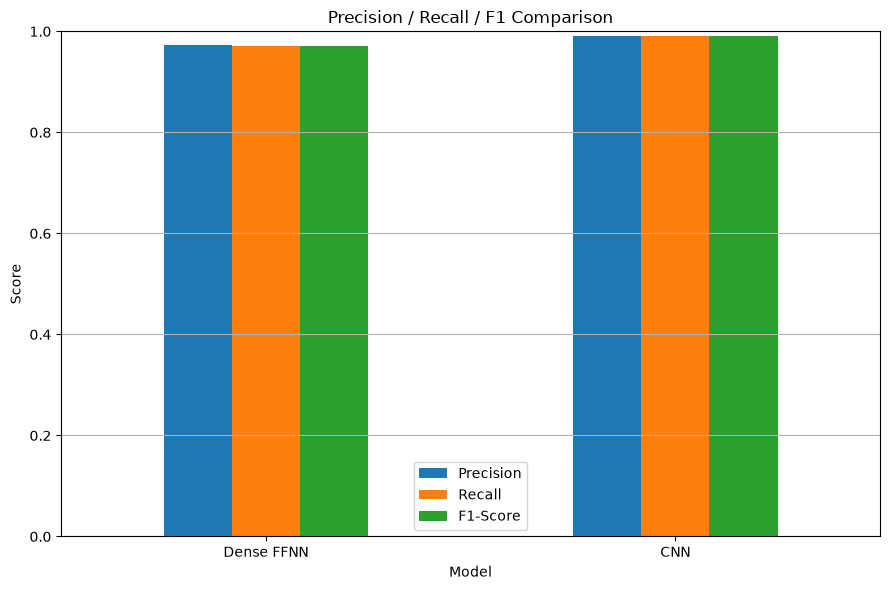

In [42]:
metrics = [
    "Precision",
    "Recall",
    "F1-Score"
]

results_df.plot(
    x="Model",
    y=metrics,
    kind="bar",
    figsize=(9, 6)
)

plt.title("Precision / Recall / F1 Comparison")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "plots/metrics_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Training Time Comparison

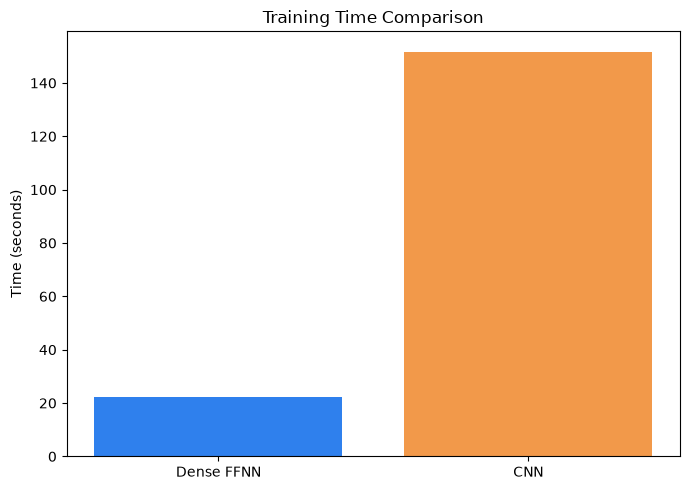

In [43]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["Training Time (sec)"],
    color=["#2F80ED", "#F2994A"]
)

plt.title("Training Time Comparison")
plt.ylabel("Time (seconds)")

plt.tight_layout()

plt.savefig(
    "plots/training_time_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Parameter Count Comparison

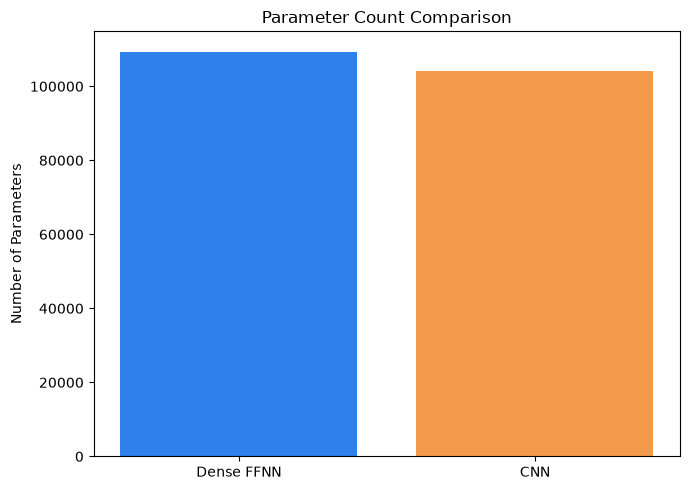

In [44]:
plt.figure(figsize=(7, 5))

plt.bar(
    results_df["Model"],
    results_df["Parameters"],
    color=["#2F80ED", "#F2994A"]
)

plt.title("Parameter Count Comparison")
plt.ylabel("Number of Parameters")

plt.tight_layout()

plt.savefig(
    "plots/parameter_count_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Display Sample Predictions
## Sample Predictions

The predictions of the CNN are visualized on several test images.

The true label and predicted label are displayed for each image.

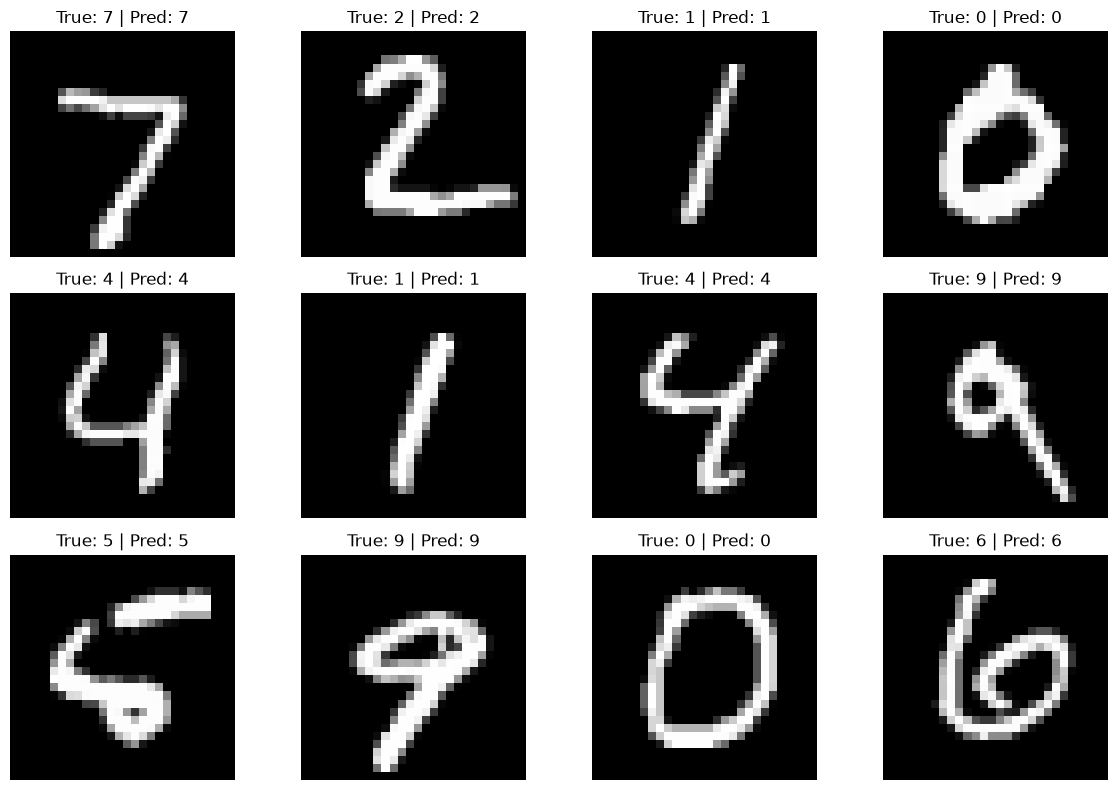

In [45]:
plt.figure(figsize=(12, 8))

for i in range(12):

    plt.subplot(3, 4, i + 1)

    plt.imshow(test_images[i], cmap="gray")

    true_label = test_labels_original[i]
    predicted_label = cnn_predictions[i]

    plt.title(
        f"True: {true_label} | Pred: {predicted_label}"
    )

    plt.axis("off")

plt.tight_layout()

plt.savefig(
    "plots/sample_predictions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# Save Predictions

In [46]:
predictions_df = pd.DataFrame({
    "True Label": test_labels_original[:100],
    "FFNN Prediction": ffnn_predictions[:100],
    "CNN Prediction": cnn_predictions[:100]
})

predictions_df.to_csv(
    "results/predictions.csv",
    index=False
)

predictions_df.head(10)

,True Label,FFNN Prediction,CNN Prediction
0,7,7,7
1,2,2,2
2,1,1,1
3,0,0,0
4,4,4,4
5,1,1,1
6,4,4,4
7,9,9,9
8,5,6,5
9,9,9,9


# Final Results

In [47]:
display(
    results_df.style.format({
        "Test Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1-Score": "{:.4f}",
        "Training Time (sec)": "{:.2f}",
        "Parameters": "{:,}"
    })
)

,Model,Test Accuracy,Precision,Recall,F1-Score,Training Time (sec),Parameters
0,Dense FFNN,0.9719,0.9721,0.9719,0.9719,22.34,"109,386"
1,CNN,0.9915,0.9915,0.9915,0.9915,151.76,"104,202"


# Determine the Better Model

In [48]:
if cnn_accuracy > ffnn_accuracy:

    print("CNN achieved higher test accuracy.")

elif ffnn_accuracy > cnn_accuracy:

    print("Dense FFNN achieved higher test accuracy.")

else:

    print("Both models achieved the same test accuracy.")

CNN achieved higher test accuracy.


# Custom Image Prediction OpenCV
## Custom Image Prediction

In this section, OpenCV is used to load a custom handwritten digit image.

The image is converted to grayscale, resized to 28×28 pixels,
normalized, and passed to the trained models.

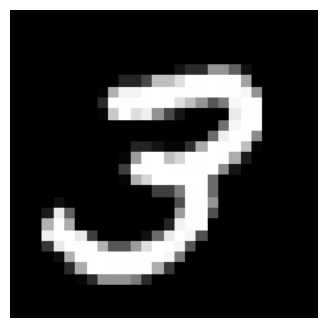

In [56]:
# Load Image
test_img = cv2.imread("images.png",cv2.IMREAD_GRAYSCALE)

plt.figure(figsize=(4, 4))
plt.imshow(test_img, cmap="gray")
plt.axis("off")
plt.show()

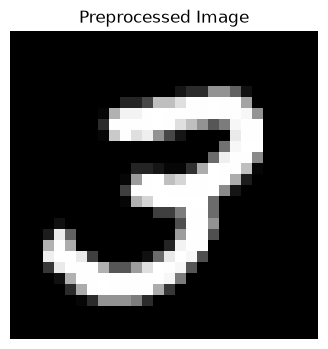

In [57]:
# Preprocess Custom Image
test_img = cv2.resize(test_img,(28, 28))
# Normalize
test_img = test_img.astype("float32") / 255.0

plt.figure(figsize=(4, 4))

plt.imshow(
    test_img,
    cmap="gray"
)

plt.title("Preprocessed Image")
plt.axis("off")

plt.show()

# Prediction with FFNN

In [58]:
test_img_ffnn = test_img.reshape(1, 784)

ffnn_prediction = model_ffnn.predict(
    test_img_ffnn
)
ffnn_digit = np.argmax(ffnn_prediction)

print("FFNN Predicted Digit:", ffnn_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
FFNN Predicted Digit: 3


# Prediction with CNN

In [59]:
test_img_cnn = test_img.reshape(1, 28, 28, 1)

cnn_prediction = model_cnn.predict(test_img_cnn)

cnn_digit = np.argmax(cnn_prediction)

print("CNN Predicted Digit:", cnn_digit)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
CNN Predicted Digit: 3


# Prediction Probability

In [60]:
print("CNN Prediction Probabilities:")
print(cnn_prediction[0])

CNN Prediction Probabilities:
[4.8893567e-12 4.0134179e-14 1.2182728e-10 1.0000000e+00 7.4083743e-19
 7.9222712e-10 1.1559874e-15 3.1647498e-13 5.1978692e-11 3.6732897e-09]


In [61]:
cnn_confidence = np.max(cnn_prediction) * 100

print(
    f"CNN Prediction: {cnn_digit}"
)

print(
    f"Confidence: {cnn_confidence:.2f}%"
)

CNN Prediction: 3
Confidence: 100.00%


# Conclusion

This project compared a Dense Feedforward Neural Network (FFNN)
and a Convolutional Neural Network (CNN) on the MNIST dataset.

The Dense FFNN works with flattened image vectors and therefore
does not explicitly preserve the spatial structure of the images.

The CNN processes the images in their original spatial form and
uses convolutional layers to learn local visual patterns.

Based on the experimental results, the models can be compared in
terms of accuracy, precision, recall, F1-score, training time,
and number of parameters.

For image classification tasks, CNNs are generally more suitable
because they can learn spatial features directly from images.